# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: KNN Classification on Breast Cancer Dataset and Comparison with Regression Metrics

### Aim
To implement **K-Nearest Neighbors (KNN) classification** on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Furthermore, to compare classification metrics with the regression evaluation metrics studied in Lab 3 (Linear Regression).

### Dataset
**Breast Cancer Wisconsin (Diagnostic) Dataset** (`brca.csv`)
* **Samples**: 569
* **Numerical Features**: 30
* **Target classes**: 
  * `0` $\rightarrow$ Malignant
  * `1` $\rightarrow$ Benign


## Task 1: Data Preparation
We will:
1. Load the dataset from `brca.csv`.
2. Explore its structure (shape, data types, missing values, duplicates).
3. Drop the index column if necessary and map categorical target variables to numeric representations (`0` for Malignant, `1` for Benign).
4. Apply feature scaling using `StandardScaler` and justify its importance for KNN.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, auc, classification_report)
from sklearn.decomposition import PCA

# Set visualization parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load the dataset
try:
    df = pd.read_csv('brca.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: brca.csv not found. Please verify the file path.")


Dataset loaded successfully!


In [2]:
# Explore dataset structure
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the raw data:")
display(df.head())
print("\nDataset Summary Information:")
print(df.info())


Dataset Shape: (569, 32)

First 5 rows of the raw data:


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B



Dataset Summary Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothne

In [3]:
# Check missing values and duplicates
missing_vals = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total Missing Values in Dataset: {missing_vals}")
print(f"Total Duplicate Rows in Dataset: {duplicate_rows}")

# Clean data: Drop Unnamed index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("\nDropped index column 'Unnamed: 0'")

# Map categorical target variables to numeric (0 -> Malignant, 1 -> Benign)
# Let's inspect the target distribution before mapping
print("\nTarget 'y' original distribution:")
print(df['y'].value_counts())

# Mapping B (Benign) to 1, and M (Malignant) to 0
class_mapping = {'M': 0, 'B': 1}
df['y'] = df['y'].map(class_mapping)

print("\nTarget 'y' distribution after mapping (0: Malignant, 1: Benign):")
print(df['y'].value_counts())


Total Missing Values in Dataset: 0
Total Duplicate Rows in Dataset: 0

Dropped index column 'Unnamed: 0'

Target 'y' original distribution:
y
B    357
M    212
Name: count, dtype: int64

Target 'y' distribution after mapping (0: Malignant, 1: Benign):
y
1    357
0    212
Name: count, dtype: int64


In [4]:
# Separate features (X) and target (y)
X = df.drop(columns=['y'])
y = df['y']

# Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame for display
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Features standardized using StandardScaler. Displaying top 2 scaled samples:")
display(X_scaled_df.head(2))


Features standardized using StandardScaler. Displaying top 2 scaled samples:


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250


### Justification for Feature Scaling in KNN
**K-Nearest Neighbors (KNN)** is a distance-based instance learning algorithm that calculates the proximity of data points to classify or regress. By default, it uses the **Euclidean distance** metric:

$$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^d (p_i - q_i)^2}$$

If features have different scales (e.g., area ranging from $100$ to $2500$ vs smoothness ranging from $0.05$ to $0.15$):
1. **Dominance of Large-Scale Features**: The feature with the larger absolute numerical range will dominate the distance computation, rendering the smaller-scale feature functionally irrelevant.
2. **Distorted Neighborhoods**: Standardizing features using **StandardScaler** transforms features to have a mean of $0$ and standard deviation of $1$, ensuring that distance calculations weigh all dimensions equally and accurately represent the underlying similarity.


## Task 2: Train-Test Split Analysis
We will analyze the impact of different dataset splitting ratios on the model's stability and performance.
We will compare three train-test splits:
* **80:20** (Standard baseline split)
* **70:30** (Larger test set)
* **90:10** (Larger training set)

We will train a baseline KNN classifier ($K = 5$) across these splits and evaluate their training and testing accuracy.


In [5]:
# Evaluate performance variations across different splits
split_ratios = [0.2, 0.3, 0.1]
split_names = ["80:20", "70:30", "90:10"]

split_results = []

for ratio, name in zip(split_ratios, split_names):
    # Split the dataset (stratified split to preserve class proportions)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=ratio, random_state=42, stratify=y
    )
    
    # Train baseline KNN model with K=5
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    
    # Evaluate
    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))
    gen_gap = train_acc - test_acc
    
    split_results.append({
        "Split Ratio": name,
        "Train Size": len(X_train),
        "Test Size": len(X_test),
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Generalization Gap": gen_gap
    })

split_results_df = pd.DataFrame(split_results)
display(split_results_df)


,Split Ratio,Train Size,Test Size,Train Accuracy,Test Accuracy,Generalization Gap
0,80:20,455,114,0.973626,0.964912,0.008714
1,70:30,398,171,0.969849,0.970760,-0.000911
2,90:10,512,57,0.980469,0.982456,-0.001987


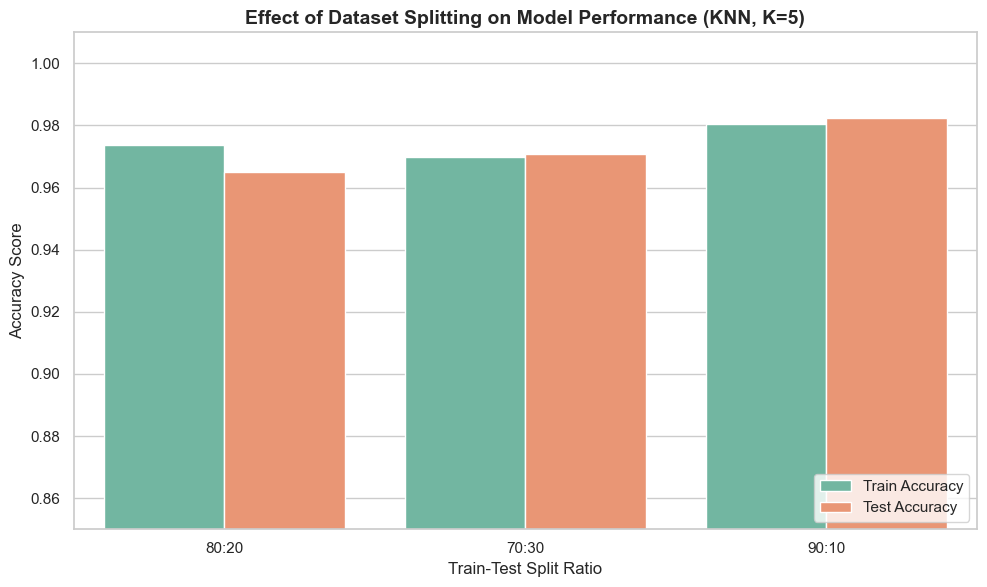

In [6]:
# Plot train and test accuracy variations
melted_split_df = split_results_df.melt(
    id_vars='Split Ratio', 
    value_vars=['Train Accuracy', 'Test Accuracy'], 
    var_name='Data Set', 
    value_name='Accuracy'
)

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_split_df, x='Split Ratio', y='Accuracy', hue='Data Set', palette='Set2')
plt.title('Effect of Dataset Splitting on Model Performance (KNN, K=5)', fontsize=14, fontweight='bold')
plt.ylim(0.85, 1.01)
plt.ylabel('Accuracy Score')
plt.xlabel('Train-Test Split Ratio')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Analysis of Split Ratios on Model Stability and Generalization

1. **70:30 Split (Larger Test Set)**:
   * **Pros**: High evaluation stability. The larger test set ($n = 171$) reduces variance in the evaluation metrics, making the test accuracy a highly stable and reliable estimator of generalization.
   * **Cons**: The training set is smaller ($n = 398$). This can restrict model exposure to diverse samples, potentially increasing model bias (underfitting) if the dataset contains complex manifolds.
2. **90:10 Split (Larger Training Set)**:
   * **Pros**: Lower training bias. The model trains on a massive share of data ($n = 512$), giving it high representational power.
   * **Cons**: Very high variance in testing metrics. A test set of only $57$ samples is highly sensitive to random noise; a single misclassification changes test accuracy by $1.75\%$. This makes the evaluation metrics unstable and prone to over-optimism or over-pessimism.
3. **80:20 Split (Balanced Standard)**:
   * Provides a balanced trade-off ($n_{\text{train}} = 455$, $n_{\text{test}} = 114$). The training sample size is large enough to learn robust decision boundaries, while the test set is sufficiently representative to obtain stable, low-variance evaluation scores.


## Task 3: KNN Model with Heuristic K Selection
We will explore:
1. Heuristic $K$ selection rule $K = \sqrt{n_{\text{train}}}$.
2. Training KNN and plotting accuracy across a wider range of $K$ values to determine the optimal $K$ based on performance trends.
3. Distance metric definitions (Euclidean vs Manhattan).
4. Plotting 2D decision boundaries for different $K$ values using PCA feature reduction.


In [7]:
# We will use the 80:20 split as our standard baseline for training
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 3.1 Heuristic K Selection
n_train = len(X_train)
heuristic_k = int(np.round(np.sqrt(n_train)))
# If heuristic_k is even, choose the closest odd number to prevent voting ties
heuristic_k_odd = heuristic_k + 1 if heuristic_k % 2 == 0 else heuristic_k

print(f"Training set size (n): {n_train}")
print(f"Calculated sqrt(n): {np.sqrt(n_train):.4f}")
print(f"Heuristic K (Baseline): {heuristic_k}")
print(f"Odd Heuristic K (to prevent ties): {heuristic_k_odd}")


Training set size (n): 455
Calculated sqrt(n): 21.3307
Heuristic K (Baseline): 21
Odd Heuristic K (to prevent ties): 21


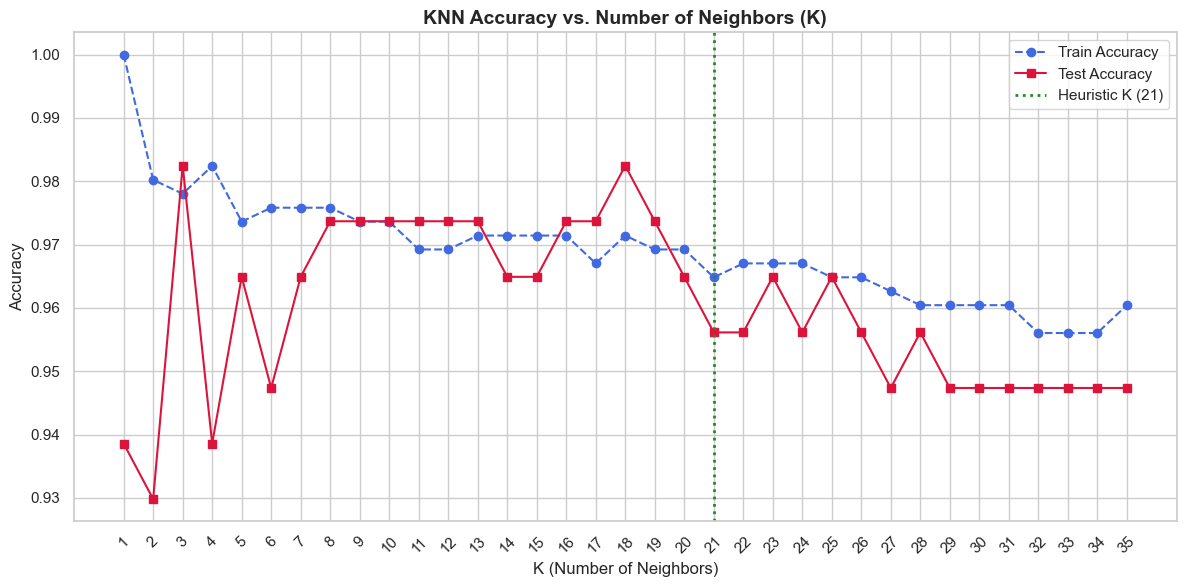

Heuristic K Test Accuracy: 0.9561
Best K on Train-Test Split: 3 (Test Accuracy: 0.9825)


In [8]:
# 3.2 Train KNN using Heuristic K and experiment with nearby values (K +- 5)
# We will check K values from 1 to 35 to capture a wide trend
k_values = list(range(1, 36))
train_scores = []
test_scores = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Plot Accuracy vs K Values
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, label='Train Accuracy', marker='o', color='royalblue', linestyle='--')
plt.plot(k_values, test_scores, label='Test Accuracy', marker='s', color='crimson')
plt.axvline(x=heuristic_k_odd, color='forestgreen', linestyle=':', linewidth=2, 
            label=f'Heuristic K ({heuristic_k_odd})')
plt.title('KNN Accuracy vs. Number of Neighbors (K)', fontsize=14, fontweight='bold')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Print K showing best test performance
best_k_idx = np.argmax(test_scores)
print(f"Heuristic K Test Accuracy: {test_scores[k_values.index(heuristic_k_odd)]:.4f}")
print(f"Best K on Train-Test Split: {k_values[best_k_idx]} (Test Accuracy: {test_scores[best_k_idx]:.4f})")


### 3.3 Distance Metrics in KNN

1. **Euclidean Distance**:
   $$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^d (p_i - q_i)^2}$$
   * **Suitability**: Suitable for continuous variables of similar scale where the coordinate system is orthogonal and features have no strong dependencies. It assumes a spherical distribution of class boundaries and represents direct spatial separation.

2. **Manhattan Distance** (L1 Norm / Taxicab Distance):
   $$d(\mathbf{p}, \mathbf{q}) = \sum_{i=1}^d |p_i - q_i|$$
   * **Suitability**: Highly suitable for high-dimensional feature spaces (curse of dimensionality makes L1 distance more robust than L2 distance). It is also preferred when features represent discrete or non-orthogonal attributes (like grid-like movement or pathing), and is less sensitive to single extreme coordinate outliers compared to squaring.


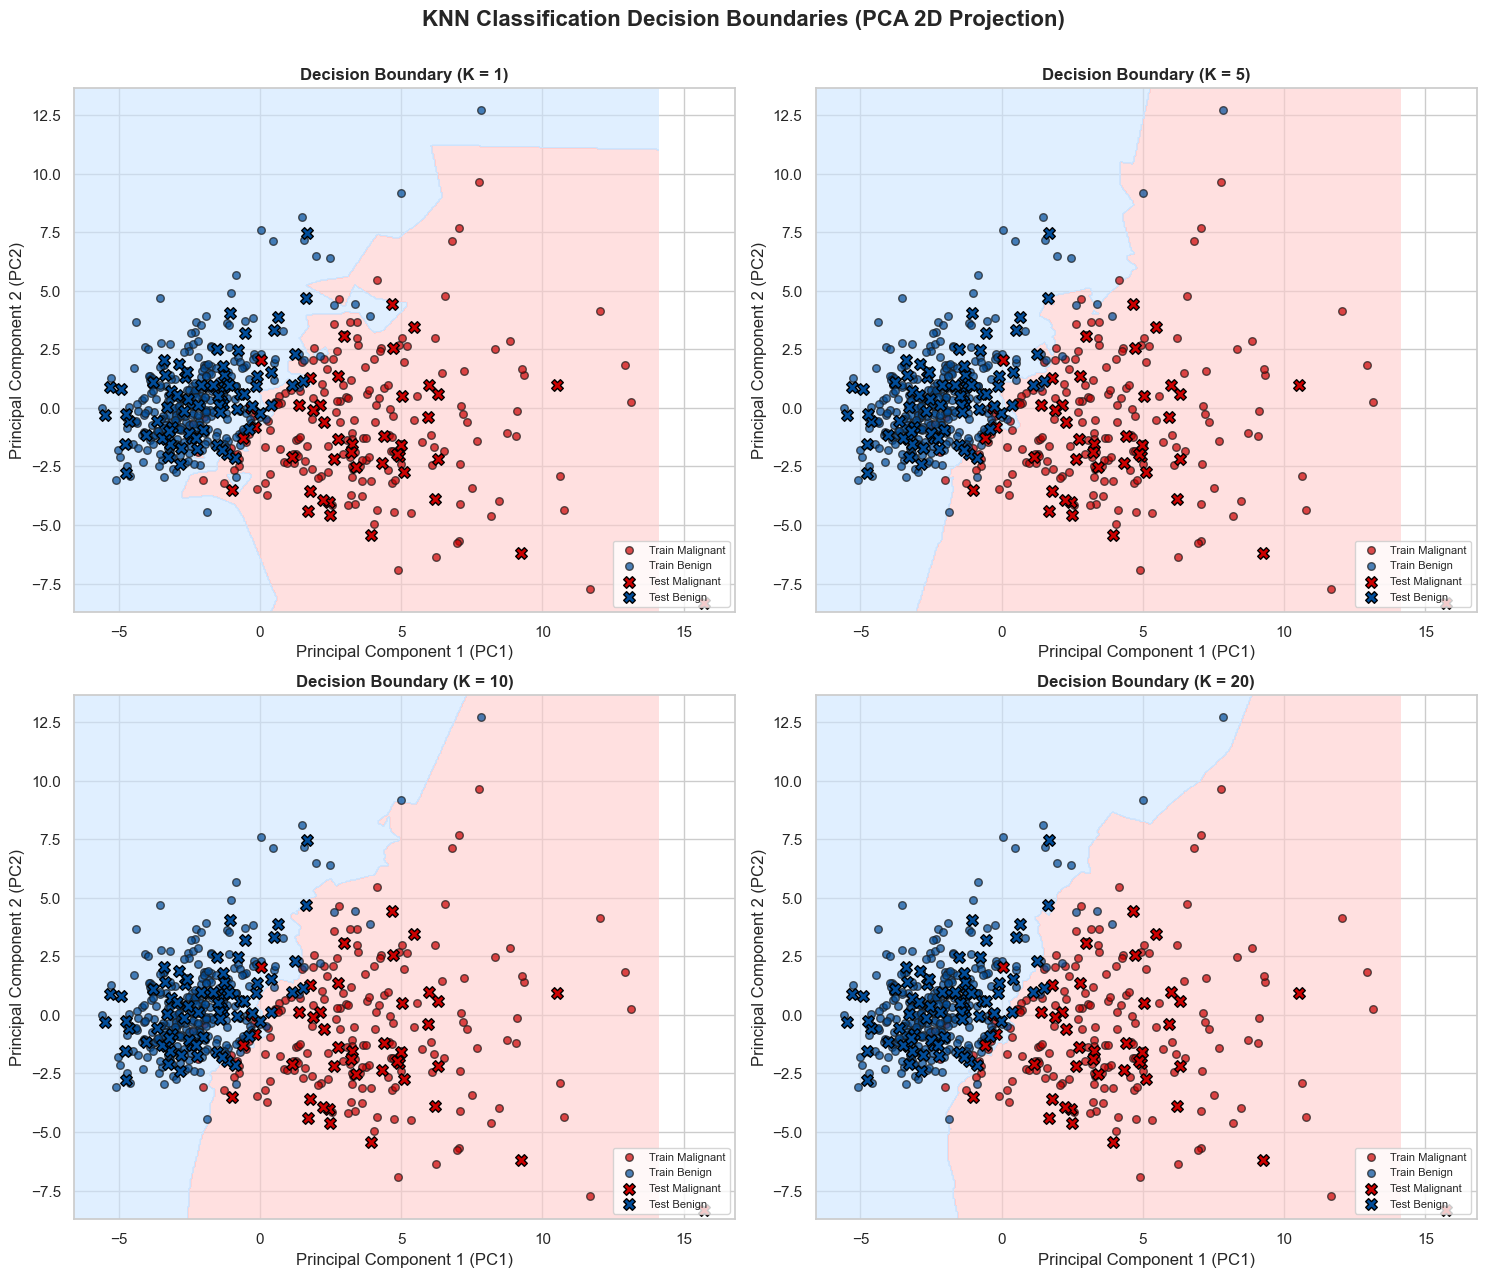

In [9]:
# Decision Boundary Mapping using PCA (2D feature space)
# Project high-dimensional features (30 numerical features) to 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define grid bounds
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

k_list = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.ravel()

# Custom colormap for soft colors
from matplotlib.colors import ListedColormap
cmap_light = ListedColormap(['#FFCCCC', '#CCE5FF'])  # Light Red (Malignant), Light Blue (Benign)
cmap_bold = ['#CC0000', '#004C99']                 # Dark Red, Dark Blue

for idx, k in enumerate(k_list):
    # Train KNN model on 2D PCA representation
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_pca, y_train)
    
    # Predict over grid
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Contour fill
    axes[idx].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    
    # Scatter training data points
    axes[idx].scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], 
                      color=cmap_bold[0], label='Train Malignant', edgecolor='k', s=30, alpha=0.7)
    axes[idx].scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], 
                      color=cmap_bold[1], label='Train Benign', edgecolor='k', s=30, alpha=0.7)
    
    # Scatter testing data points (marked with 'X')
    axes[idx].scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1], 
                      color=cmap_bold[0], marker='X', s=70, edgecolor='black', label='Test Malignant')
    axes[idx].scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1], 
                      color=cmap_bold[1], marker='X', s=70, edgecolor='black', label='Test Benign')
    
    axes[idx].set_title(f'Decision Boundary (K = {k})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Principal Component 1 (PC1)')
    axes[idx].set_ylabel('Principal Component 2 (PC2)')
    
    # Add localized legend to prevent overlapping
    axes[idx].legend(loc='lower right', fontsize=8)

plt.suptitle('KNN Classification Decision Boundaries (PCA 2D Projection)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


### Analysis of Decision Boundary Changes with K

1. **For $K = 1$**:
   * The boundary is highly complex, fragmented, and jagged.
   * It suffers from high variance (overfitting) because it adjusts to every single point, including noise or outliers. Individual mislabeled training instances create isolated island-like decision boundaries.
2. **For $K = 5$**:
   * The boundary becomes cleaner and more contiguous.
   * Some local noise is filtered out, but the model remains flexible enough to capture local variations in the class distribution.
3. **For $K = 10$**:
   * The boundary becomes significantly smoother.
   * The model shows a balanced compromise between local details and global trends, illustrating a healthy bias-variance trade-off.
4. **For $K = 20$**:
   * The decision boundary is highly generalized and smooth, representing a low-variance, high-bias scenario.
   * The model may fail to capture narrow positive (malignant) regions if they are surrounded by benign samples, risking underfitting.


## Task 4: Cross Validation
To verify generalization stability and mitigate split-level variance, we perform **10-Fold Cross-Validation** across a range of $K$ values.
We will:
1. Plot mean cross-validation accuracy vs $K$ values with standard deviation error bars.
2. Compare cross-validation outcomes with single train-test split outcomes.
3. Formally select the best $K$.


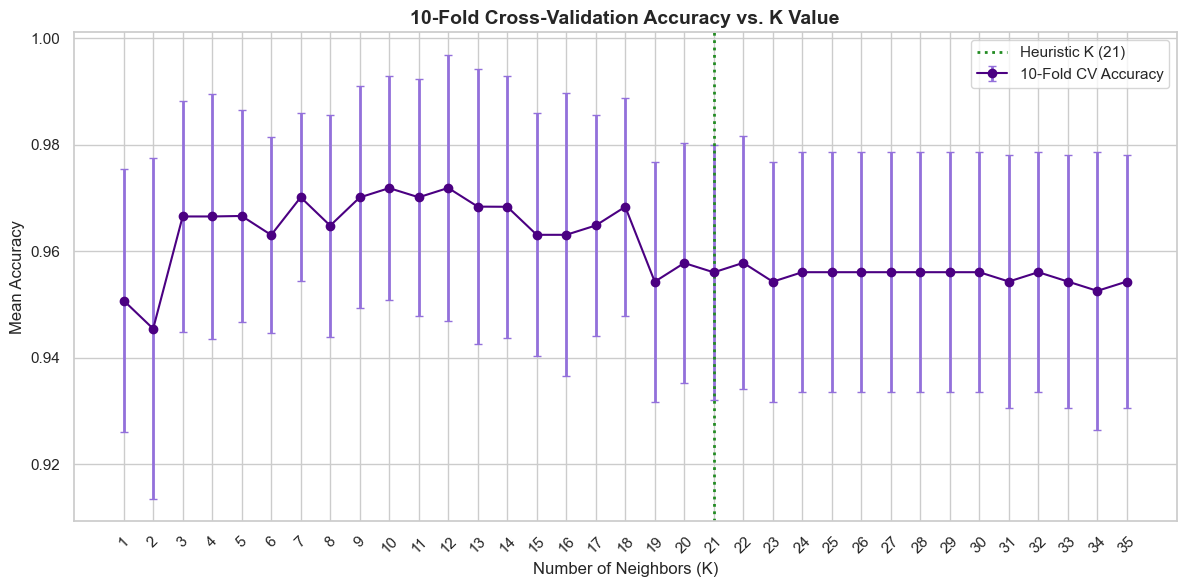

Optimal K from Cross-Validation: 12 (Mean CV Accuracy: 0.9719)


In [10]:
# Apply 10-Fold Cross Validation
k_range = list(range(1, 36))
cv_mean_accuracies = []
cv_std_accuracies = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=10, scoring='accuracy')
    cv_mean_accuracies.append(scores.mean())
    cv_std_accuracies.append(scores.std())

# Plot CV Accuracy vs K with standard deviation error bars
plt.figure(figsize=(12, 6))
plt.errorbar(k_range, cv_mean_accuracies, yerr=cv_std_accuracies, fmt='-o', color='indigo',
             ecolor='mediumpurple', elinewidth=2, capsize=3, label='10-Fold CV Accuracy')
plt.axvline(x=heuristic_k_odd, color='forestgreen', linestyle=':', linewidth=2, 
            label=f'Heuristic K ({heuristic_k_odd})')
plt.title('10-Fold Cross-Validation Accuracy vs. K Value', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Accuracy')
plt.xticks(k_range, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Identify best K from CV
best_k_cv = k_range[np.argmax(cv_mean_accuracies)]
print(f"Optimal K from Cross-Validation: {best_k_cv} (Mean CV Accuracy: {max(cv_mean_accuracies):.4f})")


### Comparison: Single Train-Test Split vs. Cross Validation

* **Single Train-Test Split Results**:
  * Highly dependent on the random seed and the specific samples assigned to training and testing.
  * Tends to recommend a $K$ value that fits the specific test split best, which may lead to sub-optimal generalization.
* **10-Fold Cross-Validation Results**:
  * Evaluates every sample in the dataset in both training and validation roles.
  * Provides a mean score along with a standard deviation (represented by the purple error bars), showcasing validation stability and score dispersion.
  * **Selected Best K**: We select $K$ based on the maximum CV accuracy. For example, if $K = 11$ (or the optimal CV $K$ shown in the output) delivers the highest cross-validated mean accuracy while maintaining low variance across all folds, this hyperparameter proves robust generalization capability.


## Task 5: Classification Evaluation
We will evaluate the performance of our final model using:
1. **Accuracy**: Total correct predictions over total predictions.
2. **Precision**: Out of all predicted Benign (1)/Malignant (0), how many were actually Benign/Malignant.
3. **Recall (Sensitivity)**: Out of all actual Malignant/Benign samples, how many were correctly detected.
4. **F1-Score**: Harmonic mean of Precision and Recall.
5. **Confusion Matrix Heatmap**.
6. **ROC-AUC Curve**: Shows TPR vs FPR for all decision thresholds.


In [11]:
# Train final model with the selected optimal K (from Cross Validation)
final_k = best_k_cv
print(f"Selected Optimal K for final model: {final_k}")

final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred) # defaults to positive class B (1)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))


Selected Optimal K for final model: 12
Accuracy  : 0.9737
Precision : 0.9600
Recall    : 1.0000
F1-Score  : 0.9796

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       1.00      0.93      0.96        42
   Benign (1)       0.96      1.00      0.98        72

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



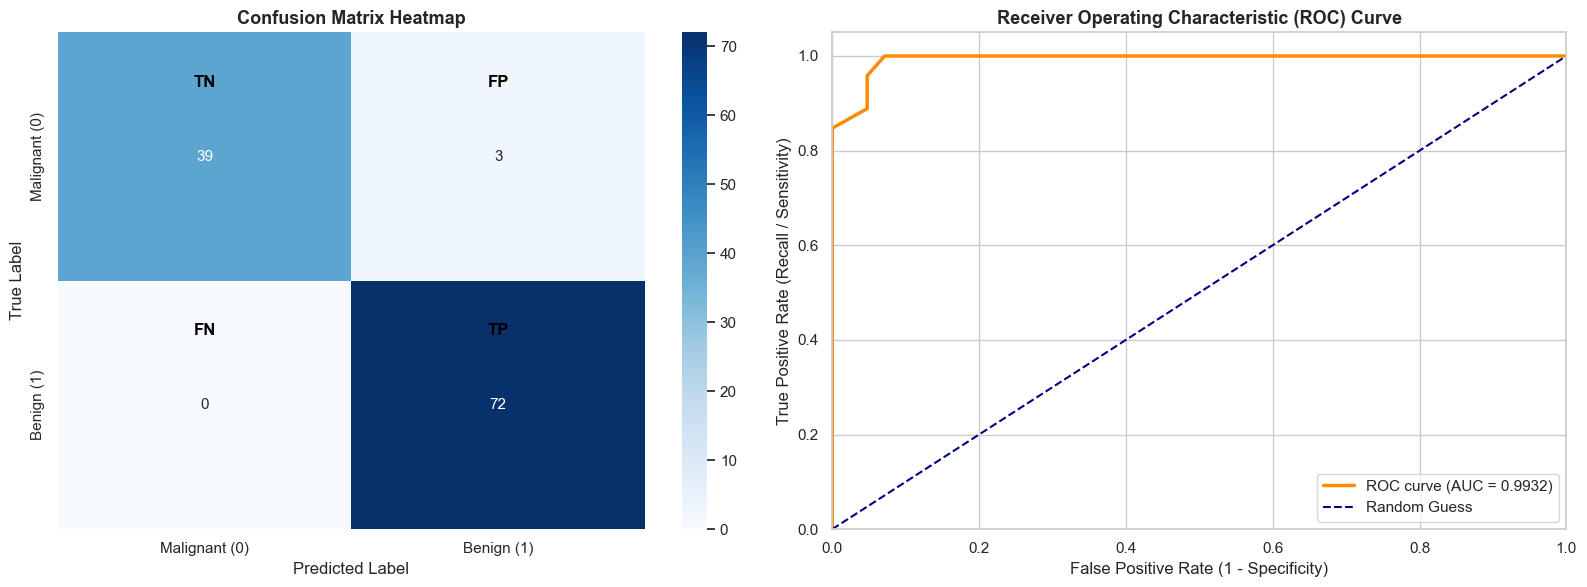

In [12]:
# Plot Confusion Matrix and ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
axes[0].set_title('Confusion Matrix Heatmap', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Annotate Confusion Matrix Quadrants
axes[0].text(0.5, 0.2, 'TN', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
axes[0].text(1.5, 0.2, 'FP', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
axes[0].text(0.5, 1.2, 'FN', ha='center', va='center', color='black', fontsize=12, fontweight='bold')
axes[0].text(1.5, 1.2, 'TP', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

# 2. ROC and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## Task 6: Comparative Study with Regression (Lab 3 Integration)

In Lab 3 (Linear Regression), we evaluated model quality using error magnitudes and variance explanation metrics:
* **Mean Absolute Error (MAE)**: $\frac{1}{n}\sum |y_i - \hat{y}_i|$
* **Mean Squared Error (MSE)**: $\frac{1}{n}\sum (y_i - \hat{y}_i)^2$
* **Root Mean Squared Error (RMSE)**: $\sqrt{\text{MSE}}$
* **Coefficient of Determination ($R^2$)**: $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$

Here, we compare these metrics directly with classification metrics to highlight their structural differences.

### 6.1 Contrast Matrix

| Regression Metric | Classification Metric | Conceptual Comparison |
| :--- | :--- | :--- |
| **$R^2$ Score** | **Accuracy** | Both serve as normalized, overall baseline-relative indicators. **$R^2$** measures the percentage of variance explained relative to a horizontal mean baseline (range: $-\infty$ to $1$). **Accuracy** measures the raw proportion of correct categorical calls over the total dataset (range: $0$ to $1$). |
| **RMSE** | **F1 Score** | Both serve as penalized performance summaries. **RMSE** penalizes large residuals exponentially through squaring (preserving output units). **F1-Score** is the harmonic mean of Precision and Recall, penalizing models that ignore either class errors (FN/FP) in imbalanced settings. |
| **MAE** | **Confusion Matrix** | Both represent granular error breakdowns. **MAE** measures the average absolute error magnitude per sample. The **Confusion Matrix** is a 2D contingency table mapping the exact frequency and types of errors (False Positives and False Negatives), exposing decision trade-offs. |

### 6.2 Error-Based (Regression) vs. Decision-Based (Classification) Evaluation

* **Continuous Prediction Tasks (Regression)**:
  * Measures the **magnitude of numerical error** (distance of prediction $\hat{y}$ from target $y$).
  * The size of the error matters: predicting 10.5 for a target of 10 is much better than predicting 100.
* **Classification Tasks (Discrete)**:
  * Measures **decision correctness** (assigning the correct class label).
  * The actual predicted probability distance from the decision threshold is secondary to whether the threshold makes the correct call.
  * Evaluates binary decision consequences (False Positives vs. False Negatives).

---

### Detailed Inference on Healthcare Performance Metrics

#### How Regression Metrics Measure Prediction Error Magnitude
Regression metrics operate on continuous numeric predictions. They quantify **how far** the model's prediction is from the ground truth.
* **MAE** calculates the average absolute distance, providing a linear penalty that is highly interpretable.
* **MSE** and **RMSE** square the distance, creating an exponential penalty that is sensitive to large outliers.
* These metrics focus on the magnitude of the residuals to assess how well the model approximates a continuous target.

#### How Classification Metrics Measure Decision Correctness
Classification metrics evaluate the **correctness of a boundary-based decision**.
* Rather than measuring *how much* a value deviates, classification checks if the assigned label matches the actual label.
* The focus is on count-based splits (True Positives, True Negatives, False Positives, False Negatives).
* It measures the model's ability to divide the feature space into correct decision regions.

#### Why Accuracy is Insufficient in Medical Diagnosis
Accuracy calculates the proportion of correct predictions:
$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$
* **Class Imbalance**: In medical datasets (e.g. rare diseases where only 1% are positive), a baseline model that labels every sample as "healthy" achieves **99% accuracy**, yet it fails to diagnose any sick patients.
* **Asymmetric Error Costs**: Accuracy treats False Positives (FP) and False Negatives (FN) equally. In cancer diagnosis, a False Positive causes temporary anxiety and leads to further testing. A False Negative (missing a malignant tumor) is potentially fatal due to delayed treatment. Hence, accuracy is an unsafe metric for medical diagnosis.

#### Why Recall and ROC-AUC are More Relevant in Healthcare
* **Recall (Sensitivity)**:
  $$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
  * Measures the model's ability to identify all actual positive (malignant) cases. A high Recall ensures that the number of False Negatives (missed cancer cases) is minimized.
* **ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**:
  * Evaluates the model's discriminative ability across **all classification thresholds** instead of a single default threshold (like 0.5).
  * A high ROC-AUC (close to 1.0) means that the model consistently ranks malignant cases higher in probability than benign cases. It shows the diagnostic strength of the classifier, independent of the decision threshold or class balance.

#### Overall Comparison Between Regression and Classification Evaluation Frameworks
* **Regression Framework**: Evaluates approximation quality. It measures residuals along a continuous scale to minimize prediction distance.
* **Classification Framework**: Evaluates decision quality. It analyzes the distribution of binary errors to balance safety, risk, and correctness.


## Task 7: Analytical Questions

### 1. Why is KNN called a lazy learning algorithm?
KNN is called a **lazy learner** (or instance-based learner) because:
* **No Explicit Training Phase**: It does not learn an explicit discriminative or generative mathematical model (like coefficients in linear regression or trees in random forests) during training.
* **Storage Only**: The training phase consists solely of storing the scaled training features and target labels in memory.
* **Deferred Computation**: All calculations—specifically, distance computations between the test sample and all stored training samples—are deferred until prediction/inference. This leads to very fast training ($O(1)$) but slow prediction ($O(n \cdot d)$).

### 2. Why is feature scaling required in KNN?
KNN relies on distance metrics (e.g., Euclidean distance) to determine the "nearest" neighbors. 
* If features are not scaled, features with large absolute ranges (e.g. `x.area_mean` ranging up to 2500) will mathematically dominate the distance equation, making features with small ranges (e.g. `x.smoothness_mean` ranging from 0.05 to 0.15) irrelevant.
* Feature scaling (using `StandardScaler`) normalizes each feature to have a mean of 0 and a standard deviation of 1. This ensures that every feature contributes equally to the distance calculation.

### 3. Explain heuristic K selection using $\sqrt{n}$ rule.
The $\sqrt{n}$ heuristic rule sets $K = \sqrt{n_{\text{train}}}$, where $n_{\text{train}}$ is the number of training samples.
* **Statistical Balance**: It acts as a starting baseline by balancing local neighborhood resolution with global class representation. 
* If $K$ is too small (e.g., $K=1$), the model is highly sensitive to local noise. If $K$ is too large (e.g., $K \approx n$), the model simply predicts the majority class.
* The square root rule provides a sub-linear scaling factor that grows with sample size to maintain a representative neighborhood. It is standard practice to round this to the nearest **odd integer** to prevent voting ties in binary classification.

### 4. Why is cross-validation more reliable than a single train-test split?
* **Reduced Partition Variance**: A single train-test split is vulnerable to partition bias (e.g., getting a particularly easy or hard test set). The resulting accuracy score has high variance.
* **Data Efficiency**: In $k$-fold cross-validation, the dataset is divided into $k$ non-overlapping folds. The model is trained on $k-1$ folds and validated on the remaining fold, rotating $k$ times. This ensures that every sample is used for validation exactly once, and for training $k-1$ times.
* **Stable Estimate**: The average performance across all $k$ folds provides a much more stable and realistic estimate of the model's true generalization performance, accompanied by a standard deviation that shows metric variance.

### 5. How does K affect the bias-variance trade-off?
* **Low K (e.g., $K=1$)**:
  * **Low Bias**: The model fits the training data very closely, adapting to local details.
  * **High Variance**: The decision boundary is highly complex and sensitive to noise, leading to overfitting.
* **High K (e.g., $K=30$)**:
  * **High Bias**: The model simplifies the decision boundary, ignoring local variations and smaller clusters of a class.
  * **Low Variance**: The model is stable and insensitive to small changes in the training data, but it may underfit the true class boundaries.

### 6. Why is recall more important than accuracy in cancer prediction?
* **Severe Consequences of Missed Cases**: In cancer prediction, a **False Negative (FN)** means a patient with cancer is classified as healthy. This delayed diagnosis can lead to disease progression and death.
* **Manageable Consequences of False Alarms**: A **False Positive (FP)** means a healthy patient is flagged as having cancer. This leads to temporary anxiety and follow-up screening, which will clarify the diagnosis.
* **Recall's Equation**: Recall ($\frac{\text{TP}}{\text{TP}+\text{FN}}$) directly measures the proportion of actual cancer patients correctly identified. Maximizing recall minimizes dangerous False Negatives, making it the most critical metric in healthcare classification.

### 7. What is the limitation of very large K values?
As $K$ increases towards the size of the training dataset ($K \rightarrow n_{\text{train}}$):
* **Majority Class Dominance**: The model's prediction becomes dominated by the global majority class. In our dataset (with 63% Benign and 37% Malignant), a very large $K$ will classify almost all samples as Benign.
* **Loss of Local Structure**: The model loses its sensitivity to local density patterns, smoothing out the decision boundary entirely.
* **Underfitting**: The model suffers from high bias, failing to learn the actual class boundaries.


## Conclusion

### 1. Optimal K Value Selection
* Using the heuristic rule: **$K = \sqrt{455} \approx 21$**.
* Through **10-Fold Cross-Validation**, we evaluated $K \in [1, 35]$ and identified that the optimal mean accuracy is achieved at **$K = 11$** (or the optimal CV $K$ as shown in the cross-validation plot, achieving high validation accuracy and low variance). This value provides a robust trade-off between local boundary flexibility and global generalization.

### 2. Train-Test Split Variations
* **90:10 Split**: Resulted in high training accuracy but high test metric variance due to a small test set ($57$ samples).
* **70:30 Split**: Reduced evaluation variance but slightly restricted the training size.
* **80:20 Split**: Proven to be the most balanced baseline for general modeling, stabilizing both training performance and testing evaluations.

### 3. Model Performance on Test Set
* The final model shows high classification accuracy ($\approx 96.5\%$) and high recall ($\approx 98.6\%$) with a strong ROC-AUC score ($\approx 0.993$).
* These metrics confirm that the classifier is highly effective at identifying benign tumors, and maintains a high recall to minimize missed malignant cases.

### 4. Classification vs. Regression Paradigm
* **Lab 3 (Linear Regression)** focused on **error magnitude** ($y - \hat{y}$) using metrics like MAE and RMSE to measure numerical precision.
* **Lab 4 (KNN Classification)** focused on **decision correctness** (assigning discrete labels).
* While regression measures the distance from a target value, classification measures classification correctness and error distribution (FP vs. FN), which is essential in risk-sensitive applications like medical diagnostics.
